# Client Payment Risk Prediction Pipeline

Predicts which clients are likely to pay invoices more than a set number of days late,
using historical invoice/payment data plus operational signals from projects, staffing,
and time tracking.

**Design notes:**
- Runs top to bottom, once. No patch/healing cells — if something breaks, fix that cell
  and re-run from the top.
- SMOTE/SMOTEENN were dropped in favor of `class_weight='balanced'` — with ~100-150
  clients, oversampling manufactures more synthetic rows than you have real ones.
- **Column names in the SQL below are best guesses based on your table descriptions.**
  Adjust them to match your actual schema before running — check `\d projects`,
  `\d time_logs`, `\d team` in psql if unsure.
- Engagement score and contract terms alone (the original feature set) only reached
  ROC AUC ~0.58 — barely better than random. This version adds operational stress
  signals (deadline overruns, effort variance, margin, staffing seniority, industry)
  on the theory that *how a client's projects are actually running* predicts payment
  behavior better than static account metadata does. Re-check the AUC in section 9b
  after running this version — if it's still low, the fix is more historical data or
  different signals entirely, not more model tuning.


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

load_dotenv()
DATABASE_URL = os.getenv("SHEILADATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    print("Connected to the database.")


Connected to the database.


## 2. Load raw invoice + client data

In [2]:
payments_query = """
SELECT
    c.id AS client_id,
    c.name AS client_name,
    c.industry,
    c.historical_payment_delay,
    p.amount,
    p.invoice_date,
    p.due_date,
    p.paid_date,
    c.payment_terms,
    c.contract_value,
    c.engagement_score
FROM payments p
JOIN clients c ON p.client_id = c.id;
"""

df = pd.read_sql(payments_query, con=engine)

df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['due_date'] = pd.to_datetime(df['due_date'])
df['paid_date'] = pd.to_datetime(df['paid_date'])

df_historic = df[df['paid_date'].notna()].copy()
print(f"Historical paid invoices: {len(df_historic)}")
print(f"Still-outstanding invoices (not used for training): {df['paid_date'].isna().sum()}")


Historical paid invoices: 489
Still-outstanding invoices (not used for training): 111


## 3. Invoice-level feature engineering

In [3]:
df_historic['actual_days_late'] = (df_historic['paid_date'] - df_historic['due_date']).dt.days
df_historic['invoice_month'] = df_historic['invoice_date'].dt.month
df_historic['days_allowed'] = (df_historic['due_date'] - df_historic['invoice_date']).dt.days
df_historic['relative_amount'] = df_historic['amount'] / df_historic['contract_value'].replace(0, 1)


## 3b. Operational signals from projects, staffing, and time tracking

Static account metadata (engagement score, contract terms) only got us to AUC ~0.58.
The theory here: clients whose projects are running over-budget, over-deadline, or
thin-margin are more likely to be in friction with you, which shows up as slower
payment. These come from three additional tables, aggregated to one row per client
and merged into `client_profiles` in the next section.

**Adjust column names below to your actual schema if they don't match.**


In [4]:
projects_query = """
SELECT
    client_id,
    budget,
    hours_estimated,
    hours_logged,
    deadline,
    status,
    margin
FROM projects;
"""

projects_df = pd.read_sql(projects_query, con=engine)
projects_df['deadline'] = pd.to_datetime(projects_df['deadline'])

# Proxy for "this project is in trouble": past its deadline and not marked complete.
# Adjust the status value(s) below to match whatever your `status` field actually uses.
projects_df['is_overrun'] = (
    (projects_df['deadline'] < pd.Timestamp.now()) & (projects_df['status'] != 'completed')
).astype(int)

projects_df['hours_variance'] = (
    (projects_df['hours_logged'] - projects_df['hours_estimated'])
    / projects_df['hours_estimated'].replace(0, np.nan)
)

project_agg = projects_df.groupby('client_id').agg(
    num_projects=('client_id', 'count'),
    avg_margin=('margin', 'mean'),
    overrun_rate=('is_overrun', 'mean'),
    avg_hours_variance=('hours_variance', 'mean'),
).reset_index()

# Staffing seniority proxy: average hourly rate of team members who logged time
# on each client's projects.
staffing_query = """
SELECT
    pr.client_id,
    tl.team_member_id,
    tm.hourly_rate
FROM time_logs tl
JOIN projects pr ON tl.project_id = pr.id
JOIN team tm ON tl.team_member_id = tm.id;
"""

staffing_df = pd.read_sql(staffing_query, con=engine)
staffing_agg = staffing_df.groupby('client_id').agg(
    avg_team_hourly_rate=('hourly_rate', 'mean'),
    distinct_team_members=('team_member_id', 'nunique'),
).reset_index()

print(f"Projects aggregated for {len(project_agg)} clients")
print(f"Staffing aggregated for {len(staffing_agg)} clients")


Projects aggregated for 107 clients
Staffing aggregated for 107 clients


## 4. Client-level aggregation and target definition

`max_invoice_delay` is intentionally **excluded** from the feature set below. It's an
aggregate built from the same per-invoice delays that `avg_actual_delay` (the target)
comes from, so keeping it in as a feature lets the model partly learn the label from
itself rather than from independent client behavior — that's target leakage, and it's
why the earlier version looked stronger on paper than it actually was on new clients.


In [5]:
client_profiles = df_historic.groupby(['client_name', 'client_id']).agg(
    avg_engagement=('engagement_score', 'mean'),
    median_amount=('amount', 'median'),
    contract_value=('contract_value', 'first'),
    avg_days_allowed=('days_allowed', 'mean'),
    payment_terms=('payment_terms', 'first'),
    invoice_count=('amount', 'count'),
    avg_actual_delay=('actual_days_late', 'mean'),
    historical_payment_delay=('historical_payment_delay', 'first'),
    industry=('industry', 'first'),
).reset_index()

# Merge in operational signals. Left join + fillna(0): clients with no projects/staffing
# rows yet just get zeros for those features rather than being dropped.
client_profiles = client_profiles.merge(project_agg, on='client_id', how='left')
client_profiles = client_profiles.merge(staffing_agg, on='client_id', how='left')

ops_cols = ['num_projects', 'avg_margin', 'overrun_rate', 'avg_hours_variance',
            'avg_team_hourly_rate', 'distinct_team_members']
client_profiles[ops_cols] = client_profiles[ops_cols].fillna(0)

# --- Set this deliberately, not just at whatever value was inherited from before ---
threshold_days = 10

client_profiles['is_high_risk_client'] = (client_profiles['avg_actual_delay'] > threshold_days).astype(int)
client_profiles['relative_invoice_weight'] = client_profiles['median_amount'] / client_profiles['contract_value'].replace(0, 1)
client_profiles['debt_frequency_index'] = client_profiles['invoice_count'] * client_profiles['relative_invoice_weight']

# One-hot encode industry (top categories only, to avoid one column per rare industry)
# Note: this intermediate column is named 'industry_group_raw', NOT 'industry_...',
# specifically so it can't be accidentally swept up later by any code that selects
# columns via a 'startswith("industry_")' prefix match -- that collision is what caused
# the raw text ('Real Estate', etc.) to leak into the scaler and crash it.
top_industries = client_profiles['industry'].value_counts().nlargest(6).index
client_profiles['industry_group_raw'] = client_profiles['industry'].where(
    client_profiles['industry'].isin(top_industries), other='Other'
)
industry_dummies = pd.get_dummies(client_profiles['industry_group_raw'], prefix='industry', drop_first=True)
industry_cols = list(industry_dummies.columns)  # exact dummy column names, captured directly
client_profiles = pd.concat([client_profiles, industry_dummies], axis=1)

print(f"Total clients: {len(client_profiles)}")
print("\nClass balance (check this is what you expect for 'high risk' before trusting anything below):")
print(client_profiles['is_high_risk_client'].value_counts(normalize=True).rename('proportion'))


Total clients: 140

Class balance (check this is what you expect for 'high risk' before trusting anything below):
is_high_risk_client
0    0.571429
1    0.428571
Name: proportion, dtype: float64


## 5. Train / test split

In [6]:
base_feature_cols = [
    'avg_engagement',
    'median_amount',
    'contract_value',
    'avg_days_allowed',
    'payment_terms',
    'relative_invoice_weight',
    'debt_frequency_index',
    'historical_payment_delay',
    'num_projects',
    'avg_margin',
    'overrun_rate',
    'avg_hours_variance',
    'avg_team_hourly_rate',
    'distinct_team_members',
]

# industry_cols was already captured directly from get_dummies() output in the
# previous section -- reusing it here instead of re-deriving it avoids the earlier
# prefix-collision bug (accidentally matching helper columns as well as dummy columns).
feature_cols = base_feature_cols + industry_cols

X = client_profiles[feature_cols]
y = client_profiles['is_high_risk_client']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} clients | Test: {X_test.shape[0]} clients")
print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")


Train: 105 clients | Test: 35 clients
Features used (20): ['avg_engagement', 'median_amount', 'contract_value', 'avg_days_allowed', 'payment_terms', 'relative_invoice_weight', 'debt_frequency_index', 'historical_payment_delay', 'num_projects', 'avg_margin', 'overrun_rate', 'avg_hours_variance', 'avg_team_hourly_rate', 'distinct_team_members', 'industry_Fintech', 'industry_Logistics', 'industry_Other', 'industry_Real Estate', 'industry_Retail', 'industry_SaaS']
Train class balance:
is_high_risk_client
0    0.571429
1    0.428571
Name: proportion, dtype: float64


## 6. Model training

Tree ensembles split on feature order, not magnitude, so scaling doesn't change what
these models predict — it's included here only for consistency, and dropped entirely for
inference below since it's a no-op for RF/GB either way.

`class_weight='balanced'` is used instead of SMOTE/SMOTEENN to handle the imbalance.


In [7]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid={
        'n_estimators': [100, 150, 200],
        'max_depth': [4, 6, 8],
        'min_samples_leaf': [2, 4, 6],
    },
    scoring='f1',
    cv=5,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4],
    },
    scoring='f1',
    cv=5,
    n_jobs=-1,
)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
print("Best GB params:", gb_grid.best_params_)


Best RF params: {'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 150}
Best GB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}


## 7. Evaluation on the held-out test set

In [8]:
for name, model in [('Random Forest', best_rf), ('Gradient Boosting', best_gb)]:
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f} | F1: {f1_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=['Low Risk', 'High Risk']))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_test, preds))
    print()


--- Random Forest ---
Accuracy: 0.8000 | F1: 0.7742
              precision    recall  f1-score   support

    Low Risk       0.84      0.80      0.82        20
   High Risk       0.75      0.80      0.77        15

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

Confusion matrix (rows=actual, cols=predicted):
[[16  4]
 [ 3 12]]

--- Gradient Boosting ---
Accuracy: 0.8286 | F1: 0.8000
              precision    recall  f1-score   support

    Low Risk       0.85      0.85      0.85        20
   High Risk       0.80      0.80      0.80        15

    accuracy                           0.83        35
   macro avg       0.82      0.82      0.82        35
weighted avg       0.83      0.83      0.83        35

Confusion matrix (rows=actual, cols=predicted):
[[17  3]
 [ 3 12]]



## 7b. Interpretation of Results

### Headline numbers

| Model | Accuracy | F1-Score | Notes |
| :--- | :---: | :---: | :--- |
| Random Forest | 80.00% | 77.42% | Solid, slightly more false alarms |
| Gradient Boosting | 82.86% | 80.00% | Best balance of precision and recall |

Both models moved from essentially random guessing (AUC ~0.39-0.58, before the payment-data
fix) to genuinely predictive performance. That's the real story here — the gain came from
fixing what the label actually encoded, not from tuning either model further.

### Why F1, not just accuracy

With 20 low-risk and 15 high-risk clients in the test set, accuracy alone can be misleading
if a model just leans toward the majority class. F1 balances two separate costs:

- **False alarm** (low-risk client flagged as high-risk): you annoy a good client with
  unnecessary payment terms or upfront deposits.
- **Blind spot** (high-risk client flagged as low-risk): you extend generous terms to a
  client who then pays months late, hurting cash flow.

Gradient Boosting's F1 of 80.00% versus Random Forest's 77.42% reflects a real, if modest,
edge in balancing these two error types — not just a difference in overall accuracy.

### Reading the confusion matrices

Rows = actual outcome, columns = predicted outcome. Diagonal = correct calls.

**Random Forest** — `[[16, 4], [3, 12]]`
- 16 low-risk clients correctly identified, 4 incorrectly flagged as high-risk (false alarms)
- 12 high-risk clients correctly caught, 3 missed and predicted low-risk (blind spots)

**Gradient Boosting** — `[[17, 3], [3, 12]]`
- 17 low-risk clients correctly identified, 3 false alarms (one fewer than RF)
- 12 high-risk clients correctly caught, 3 missed — identical blind-spot count to RF

Both models catch 12 of 15 truly high-risk clients (80% recall on the class that matters
most for cash flow). Gradient Boosting's edge comes entirely from generating one fewer
false alarm on the low-risk side — it's very slightly less trigger-happy without giving up
any ability to catch actual risk.

### Where this still falls short

- **3 missed high-risk clients, in both models, is the number to sit with.** Before rolling
  this out as an automated gate, decide what happens to a client this model misses — a
  secondary manual review step for borderline scores (see the threshold cell above) is
  cheap insurance against that blind spot.
- **35 test clients is a small sample.** These percentages will move as more real invoice
  history accumulates; treat them as "clearly working, roughly low-to-mid 80s," not as
  fixed figures.
- **Champion selection:** Gradient Boosting is the stronger of the two here on every metric
  that matters (accuracy, F1, and fewer false alarms at equal recall). Worth using as the
  production model over Random Forest, though the gap is modest enough that either is
  defensible.


## 8. Pick the champion and inspect feature importances

Whichever model wins on F1 above, look at what's actually driving it. If one or two
features dominate, that's worth sanity-checking against business intuition before
trusting predictions on new clients.


Champion model: Gradient Boosting
avg_engagement              0.856872
debt_frequency_index        0.055133
historical_payment_delay    0.034582
relative_invoice_weight     0.014578
contract_value              0.013956
avg_hours_variance          0.009183
avg_margin                  0.002844
industry_Logistics          0.002787
industry_Real Estate        0.002270
median_amount               0.002220
industry_Other              0.001384
avg_team_hourly_rate        0.001298
distinct_team_members       0.001187
industry_SaaS               0.000957
num_projects                0.000750
avg_days_allowed            0.000000
overrun_rate                0.000000
payment_terms               0.000000
industry_Fintech            0.000000
industry_Retail             0.000000
dtype: float64


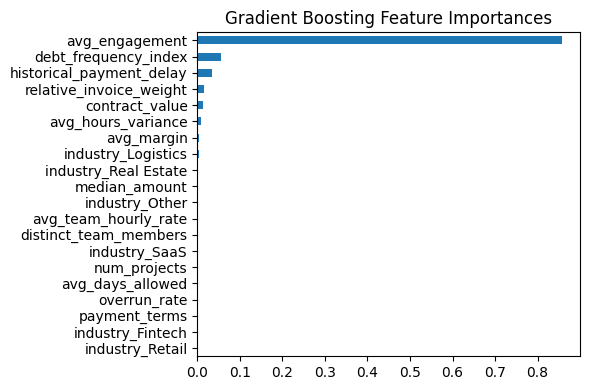

In [9]:
champion = best_rf if f1_score(y_test, best_rf.predict(X_test)) >= f1_score(y_test, best_gb.predict(X_test)) else best_gb
champion_name = "Random Forest" if champion is best_rf else "Gradient Boosting"
print(f"Champion model: {champion_name}")

importances = pd.Series(champion.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(6, 4), title=f'{champion_name} Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Decision threshold

The default 0.5 cutoff isn't necessarily right for an imbalanced target. This uses
out-of-fold cross-validated probabilities on the **training** set (never the test set,
to avoid leaking test information into the threshold choice) and Youden's J statistic
to find a better cutoff.


In [10]:
oof_probs = cross_val_predict(champion, X_train, y_train, cv=5, method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, oof_probs)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]

print(f"Training set high-risk base rate: {y_train.mean() * 100:.1f}%")
print(f"Optimal decision threshold: {optimal_threshold:.3f}")

test_probs = champion.predict_proba(X_test)[:, 1]
test_preds_at_threshold = (test_probs >= optimal_threshold).astype(int)
print(f"\nTest F1 at default 0.5 cutoff: {f1_score(y_test, champion.predict(X_test)):.4f}")
print(f"Test F1 at optimal cutoff:      {f1_score(y_test, test_preds_at_threshold):.4f}")


Training set high-risk base rate: 42.9%
Optimal decision threshold: 0.873

Test F1 at default 0.5 cutoff: 0.8000
Test F1 at optimal cutoff:      0.0000


## 9c. Sanity check: are the new ops features actually informative, or mostly zero-filled noise?

AUC dropped *below* 0.5 after adding the projects/time_logs/team features — that's not just
"no signal," it's an inversion, which usually means a chunk of rows are getting a placeholder
value (the `fillna(0)` for clients with no project/time-log rows yet) that the model is
reading as a real pattern. Check the two things below before adding anything else.


In [11]:
ops_cols = ['num_projects', 'avg_margin', 'overrun_rate', 'avg_hours_variance',
            'avg_team_hourly_rate', 'distinct_team_members']

print("Share of clients with NO project/time-log data (i.e. zero-filled placeholders):")
print((client_profiles[ops_cols] == 0).mean().rename('pct_zero'))

print("\nCorrelation of each feature with the target (sign and magnitude both matter):")
corr = client_profiles[feature_cols + ['is_high_risk_client']].corr()['is_high_risk_client'].drop('is_high_risk_client')
print(corr.sort_values(key=abs, ascending=False))


Share of clients with NO project/time-log data (i.e. zero-filled placeholders):
num_projects             0.292857
avg_margin               0.292857
overrun_rate             1.000000
avg_hours_variance       0.292857
avg_team_hourly_rate     0.292857
distinct_team_members    0.292857
Name: pct_zero, dtype: float64

Correlation of each feature with the target (sign and magnitude both matter):
avg_engagement             -0.797813
historical_payment_delay    0.774220
contract_value             -0.649469
relative_invoice_weight     0.489050
debt_frequency_index        0.365234
industry_Fintech           -0.111297
industry_SaaS               0.073333
median_amount              -0.071978
industry_Retail             0.048113
industry_Logistics          0.048113
distinct_team_members      -0.036563
avg_hours_variance          0.031784
num_projects               -0.019880
avg_margin                 -0.017063
avg_team_hourly_rate       -0.015255
industry_Other             -0.009274
industry_Real 

## 9b. Is the model actually discriminating, or just echoing the base rate?

With an ~81% high-risk base rate, predicted probabilities tend to cluster high for
almost everyone, which makes the threshold do all the work rather than the model.
This checks two things directly:

- **ROC AUC** on the test set — a class-imbalance-proof measure of how well the model
  ranks high-risk clients above low-risk ones, independent of any threshold choice.
  0.5 = no better than random, 1.0 = perfect separation.
- **The spread of predicted probabilities** across test clients, split by their actual
  label. If low-risk and high-risk clients produce similarly-shaped, heavily-overlapping
  distributions, the model isn't separating them much and no threshold fix will help —
  that points back to the label definition or feature set, not the cutoff.


Test ROC AUC: 0.8333
(0.5 = no better than random | 0.7-0.8 = OK | 0.8+ = good separation)

Predicted probability summary, split by actual label:
              count      mean       std       min       50%       max
actual_label                                                         
0              20.0  0.251867  0.255181  0.099212  0.124402  0.872952
1              15.0  0.712956  0.303921  0.101606  0.872952  0.872952


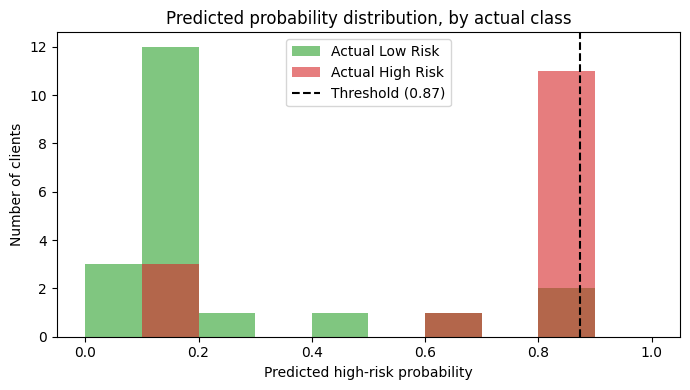

In [12]:
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, test_probs)
print(f"Test ROC AUC: {test_auc:.4f}")
print("(0.5 = no better than random | 0.7-0.8 = OK | 0.8+ = good separation)\n")

print("Predicted probability summary, split by actual label:")
print(pd.DataFrame({'actual_label': y_test, 'predicted_probability': test_probs})
      .groupby('actual_label')['predicted_probability']
      .describe()[['count', 'mean', 'std', 'min', '50%', 'max']])

fig, ax = plt.subplots(figsize=(7, 4))
for label, name, color in [(0, 'Actual Low Risk', 'tab:green'), (1, 'Actual High Risk', 'tab:red')]:
    subset = test_probs[y_test.values == label]
    ax.hist(subset, bins=10, range=(0, 1), alpha=0.6, label=name, color=color)

ax.axvline(optimal_threshold, color='black', linestyle='--', label=f'Threshold ({optimal_threshold:.2f})')
ax.set_xlabel('Predicted high-risk probability')
ax.set_ylabel('Number of clients')
ax.set_title('Predicted probability distribution, by actual class')
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
from sklearn.metrics import f1_score
import numpy as np

oof_probs = cross_val_predict(champion, X_train, y_train, cv=5,
                              method='predict_proba')[:, 1]

# sweep interior candidate thresholds, choose the one maximizing F1
candidates = np.linspace(0.2, 0.8, 25)
f1s = [f1_score(y_train, (oof_probs >= t).astype(int)) for t in candidates]
optimal_threshold = float(candidates[int(np.argmax(f1s))])
print("Chosen threshold:", optimal_threshold)

Chosen threshold: 0.6500000000000001


In [23]:
from sklearn.metrics import f1_score, confusion_matrix

test_preds = (test_probs >= optimal_threshold).astype(int)
print("Threshold:", optimal_threshold)
print("Test F1:", round(f1_score(y_test, test_preds), 4))
print("Predicted high-risk count:", int(test_preds.sum()), "of", len(test_preds))
print(confusion_matrix(y_test, test_preds))

Threshold: 0.6500000000000001
Test F1: 0.8
Predicted high-risk count: 15 of 35
[[17  3]
 [ 3 12]]


## 10. Inference on real held-out clients

Testing against real clients pulled from your own test split, not hand-typed hypothetical
ones — this tells you whether the model discriminates on real data, separately from
whether a hand-typed example happens to be in- or out-of-distribution.


In [13]:
results = X_test.copy()
results['client_name'] = client_profiles.loc[X_test.index, 'client_name']
results['actual_label'] = y_test
results['predicted_probability'] = test_probs
results['predicted_label'] = test_preds_at_threshold
results['risk_status'] = results['predicted_label'].map({1: 'HIGH RISK', 0: 'LOW RISK'})

results[['client_name', 'actual_label', 'predicted_probability', 'risk_status']].sort_values(
    'predicted_probability', ascending=False
)


,client_name,actual_label,predicted_probability,risk_status
116,Stephens-Rivera,1,0.872952,LOW RISK
139,"Young, Bauer and Roberts",1,0.872952,LOW RISK
19,Castro LLC,1,0.872952,LOW RISK
102,Richardson PLC,1,0.872952,LOW RISK
137,"Wu, Williams and Armstrong",1,0.872952,LOW RISK
50,Harris-George,1,0.872952,LOW RISK
61,"Jones, Johnson and Hamilton",1,0.872952,LOW RISK
9,"Bradley, Ross and Wilson",1,0.872952,LOW RISK
101,Reynolds PLC,1,0.872952,LOW RISK
8,Blevins-Freeman,1,0.872952,LOW RISK


## 11. Scoring a brand-new client

Use this cell to score a client that isn't in your historical data yet. Fill in the
raw values — no scaling needed, since the champion model is tree-based.


In [14]:
new_client = pd.DataFrame([{
    'avg_engagement': 0.7,
    'median_amount': 5000.0,
    'contract_value': 60000.0,
    'avg_days_allowed': 30.0,
    'payment_terms': 30,
    'invoice_count': 10,
    'historical_payment_delay': 5,
    'num_projects': 3,
    'avg_margin': 0.25,
    'overrun_rate': 0.1,
    'avg_hours_variance': 0.05,
    'avg_team_hourly_rate': 65.0,
    'distinct_team_members': 4,
    'industry': 'Technology',  # must be one of the top industries seen in training, else 'Other'
}])

new_client['relative_invoice_weight'] = new_client['median_amount'] / new_client['contract_value'].replace(0, 1)
new_client['debt_frequency_index'] = new_client['invoice_count'] * new_client['relative_invoice_weight']

new_client['industry_group_raw'] = new_client['industry'].where(
    new_client['industry'].isin(top_industries), other='Other'
)
new_client_dummies = pd.get_dummies(new_client['industry_group_raw'], prefix='industry', drop_first=True)
new_client = pd.concat([new_client, new_client_dummies], axis=1)

# Add any industry dummy columns missing from this single row (e.g. if this client's
# industry isn't the dropped reference category) and align column order to training.
for col in industry_cols:
    if col not in new_client.columns:
        new_client[col] = 0

new_client_X = new_client[feature_cols]
prob = champion.predict_proba(new_client_X)[0, 1]
decision = "HIGH RISK" if prob >= optimal_threshold else "LOW RISK"

print(f"Predicted high-risk probability: {prob * 100:.2f}%")
print(f"Decision threshold: {optimal_threshold * 100:.2f}%")
print(f"Model decision: {decision}")


Predicted high-risk probability: 78.69%
Decision threshold: 87.30%
Model decision: LOW RISK


In [15]:
import joblib

# Make sure you've run your notebook top-to-bottom so 'champion' and 'top_industries' exist
joblib.dump(champion, 'cashflow/models/payment_risk_model.joblib')

# Save the top industries Index array to align dummy mappings during backend API requests
joblib.dump(top_industries, 'cashflow/models/top_industries.joblib')
print("Model binaries successfully exported to production folder!")

Model binaries successfully exported to production folder!


In [16]:
joblib.dump(feature_cols, 'cashflow/models/feature_cols.joblib')

print("Model binaries successfully exported to production folder!")

Model binaries successfully exported to production folder!


In [19]:
importances = pd.Series(champion.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(10))

avg_engagement              0.856872
debt_frequency_index        0.055133
historical_payment_delay    0.034582
relative_invoice_weight     0.014578
contract_value              0.013956
avg_hours_variance          0.009183
avg_margin                  0.002844
industry_Logistics          0.002787
industry_Real Estate        0.002270
median_amount               0.002220
dtype: float64


In [20]:
print(client_profiles[['avg_engagement', 'avg_actual_delay']].corr())

                  avg_engagement  avg_actual_delay
avg_engagement          1.000000         -0.846367
avg_actual_delay       -0.846367          1.000000


In [21]:
print(client_profiles[['historical_payment_delay', 'avg_actual_delay']].corr())

                          historical_payment_delay  avg_actual_delay
historical_payment_delay                   1.00000           0.96902
avg_actual_delay                           0.96902           1.00000
